In [2]:
from pathlib import Path
import shutil
import kagglehub

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import cv2
import os

from torchvision.datasets import ImageFolder
import torchvision.transforms.v2 as T
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset, random_split
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, precision_score
import torchmetrics

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

path_to_cards = Path("./CardBackDataset")

c:\D\4630\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
SIZE = 256
BATCH = 32

train_T = T.Compose([
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.Resize(SIZE),
    T.CenterCrop(size=(256, 200)),
    #T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.RandomVerticalFlip(p=0.5),
    T.ColorJitter(contrast=0.25, brightness=0.25),
    T.GaussianBlur(kernel_size=3, sigma=(0.5, 1.5)),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

torch.manual_seed(12345)
train_val = ImageFolder(path_to_cards / "train", train_T)
train_idxs, val_idxs = train_test_split(np.arange(len(train_val.targets)), test_size=0.3, stratify=train_val.targets, random_state=12345)

train_set = Subset(train_val, train_idxs)
val_set = Subset(train_val, val_idxs)

train_loader = DataLoader(train_set, batch_size=BATCH, shuffle=True)
val_loader = DataLoader(val_set, batch_size=BATCH)

In [3]:
# what classes exist?
class_names = train_val.classes
print(len(class_names),"classes")
class_names

2 classes


['fake', 'real']

In [4]:
def readImage(path):
    bgr_img = cv2.imread(path)
    b,g,r = cv2.split(bgr_img)
    rgb_img = cv2.merge([r,g,b])
    return rgb_img

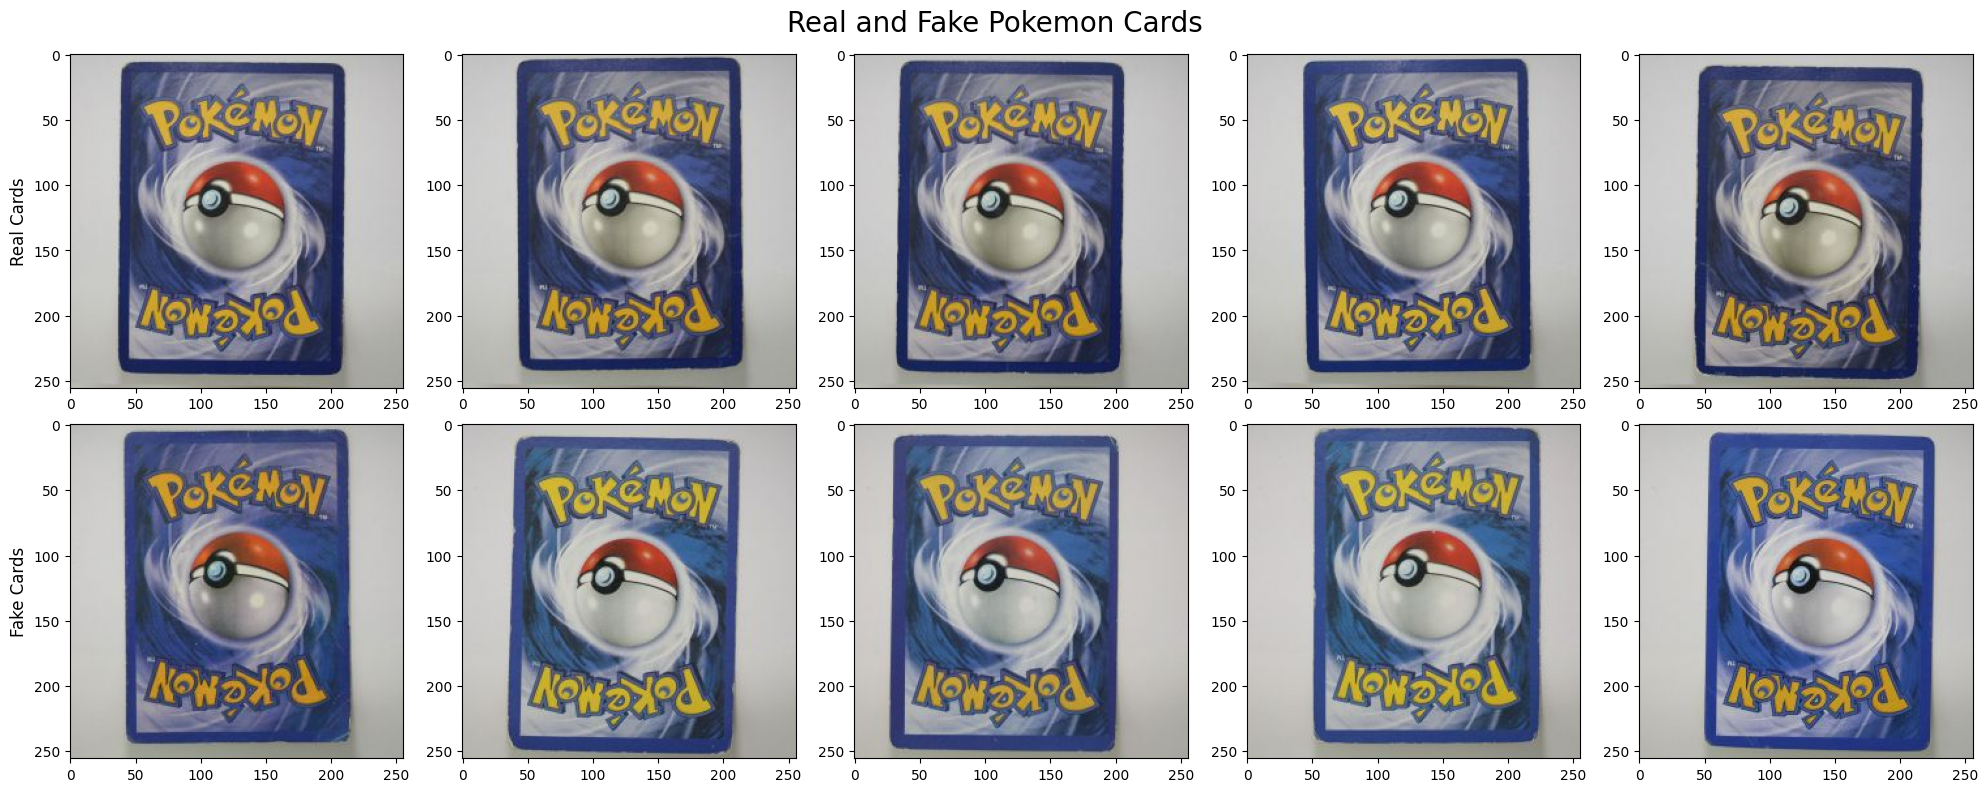

In [5]:
test_csv = pd.read_csv(path_to_cards / "test_labels.csv")

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle("Real and Fake Pokemon Cards", fontsize=20)

for i, idx in enumerate(test_csv[test_csv["label"] == 1]['id'][:5]):
    path = path_to_cards / "test" / "real" / f"{idx}.JPG"
    axes[0,i].imshow(readImage(path))
axes[0,0].set_ylabel("Real Cards", size="large")
for i, idx in enumerate(test_csv[test_csv["label"] == 0]['id'][:5]):
    path = path_to_cards / "test" / "fake" / f"{idx}.JPG"
    axes[1,i].imshow(readImage(path))
axes[1,0].set_ylabel("Fake Cards", size="large")

plt.tight_layout()
plt.show()

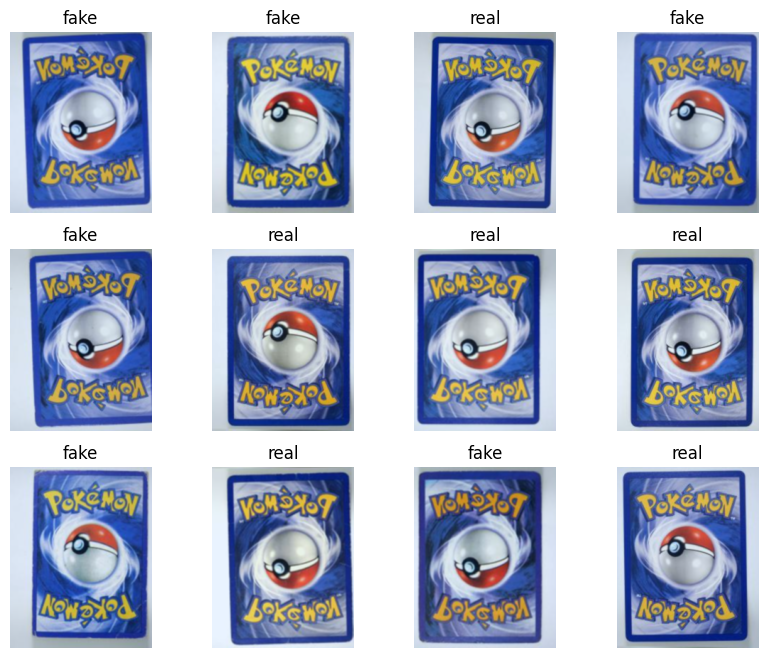

torch.Size([32, 3, 256, 200])


In [6]:
# take a look at a random sample
# note that calling next(iter(train_loader)) pulls 1 entire batch of images
images, labels = next(iter(train_loader))

# look at 12 images
fig, axes = plt.subplots(3, 4, figsize=(10,8))
for i, ax in enumerate(axes.flatten()):
    # Permute dimensions from (C, H, W) to (H, W, C) and convert to numpy
    im = images[i].permute(1, 2, 0).cpu().numpy()
    # scale back again because scaling is part of the pipeline
    im -= im.min()
    im /= im.max()
    ax.imshow(im)
    ax.set_title(class_names[labels[i]])
    ax.axis("off")
plt.show()

# what does that images tensor look like?
# [batch size, channels, rows, cols] (PyTorch format)
print(images.shape)

In [33]:
class BasicCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            #nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            #nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            #nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),
            
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            #nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),

            nn.Flatten(),
            nn.LazyLinear(256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.LazyLinear(1)
        )

    def forward(self, X):
        return self.network(X)

model = BasicCNN().to(device)
print(model)

BasicCNN(
  (network): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Flatten(start_dim=1, end_dim=-1)
    (13): LazyLinear(in_features=0, out_features=256, bias=True)
    (14): ReLU()
    (15): Dropout(p=0.5, inplace=False)
    (16): LazyLinear(in_features=0, out_features=1, bias=True)
  )
)


In [34]:
def evaluate_tm(model, data_loader, metric):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device).float().unsqueeze(1)
            y_pred = model(X_batch)
            metric.update(y_pred.squeeze(), y_batch.squeeze())
    return metric.compute()

def train(model, optimizer, loss_fn, metric, train_loader, valid_loader,
          n_epochs):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.0
        metric.reset()
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device).float().unsqueeze(1)
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred.squeeze(), y_batch.squeeze())
        history["train_losses"].append(total_loss / len(train_loader))
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(
            evaluate_tm(model, valid_loader, metric).item())
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
    return history


In [ ]:
if os.path.exists('cardDetector.pt'):
    model.load_state_dict(torch.load("cardDetector.pt", weights_only=True))
    model.to(device)
else:
    n_epochs = 20
    optimizer = torch.optim.AdamW(model.parameters())
    xentropy = nn.BCEWithLogitsLoss()
    accuracy = torchmetrics.Accuracy(task="binary").to(device)
    history = train(model, optimizer, xentropy, accuracy,
                    train_loader, val_loader, n_epochs)
    torch.save(model.state_dict(), "cardDetector.pt")

In [ ]:
test_T = T.Compose([
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.Resize(SIZE),
    T.CenterCrop(size=(256, 200)),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test = ImageFolder(path_to_cards / "test", test_T)
test_loader = DataLoader(test, batch_size=BATCH)

In [44]:
def evaluate_model(loader):
    preds = []
    all_labels = []

    model.eval()
    with torch.no_grad():
        for inputs, labels in loader:
            outputs = model(inputs.to(device))
            probs = torch.sigmoid(outputs)
            pred = torch.round(probs)

            preds.extend(pred.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(all_labels, preds)
    precision = precision_score(all_labels, preds)
    recall = recall_score(all_labels, preds)
    specificity = recall_score(all_labels, preds, pos_label=0)
    print(accuracy, precision, recall, specificity)

evaluate_model(test_loader)

0.9871794871794872 0.9803921568627451 1.0 0.9642857142857143


In [ ]:
own = ImageFolder(path_to_cards / "own", test_T)
own_loader = DataLoader(own, batch_size=BATCH)

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle("Real and Fake Pokemon Cards", fontsize=20)

for i in range(5):
    path = path_to_cards / "own" / "real" / f"{i}.JPG"
    axes[0,i].imshow(readImage(path))
axes[0,0].set_ylabel("Real Cards", size="large")
for i in range(5):
    path = path_to_cards / "own" / "fake" / f"{i}.JPG"
    axes[1,i].imshow(readImage(path))
axes[1,0].set_ylabel("Fake Cards", size="large")

plt.tight_layout()
plt.show()


0.8636363636363636 0.8823529411764706 0.9375 0.6666666666666666


In [ ]:

evaluate_model(own_loader)